# Linear classifier (scikit-learn)

Linear classifier is a simple model that can be used for binary or multi-class classification. It is a linear model that makes predictions by computing a weighted sum of the input features, plus a bias term. The prediction is the class whose score is the highest. This notebook trains it using scikit-learn's `SGDClassifier` — see "Linear Classifier" for a from-scratch implementation.

**Aprendizado Profundo para Reconhecimento Visual** — Ifes Campus Serra
Autor: Thiago M. Paixão

In [ ]:
# If True, test is running on Colab. Otherwise, test is assumed to be offline.
TEST_ON_COLAB = True
FOLDERNAME = 'Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification'  # only used if TEST_ON_COLAB is True

assert not (FOLDERNAME is None and TEST_ON_COLAB), "FOLDERNAME has to be set if TEST_ON_COLAB is True"

if not TEST_ON_COLAB:
    %load_ext autoreload
    %autoreload 2

In [24]:
# Create dataset directory
import os

if TEST_ON_COLAB:
    # This mounts your Google Drive to the Colab VM.
    from google.colab import drive

    drive.mount('/content/drive')
    os.chdir(f'/content/drive/My Drive/{FOLDERNAME}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
![ -f utils.py ] || gdown --id 1NUGtNIABwt4PSAkBXPcMtnKPPaZYmxP3 -O utils.py

## Artificial dataset

Train set size: 800
Test set size: 200
[2 2 2 1 2 0 1 0 0 2 0 1 2 2 0 0 0 2 2 2 2 1 2 0 0 1 2 0 2 1 2 0 0 2 2 1 0
 0 0 2 1 2 1 0 0 1 0 2 2 2 1 1 1 2 0 0 0 0 2 1 1 1 0 0 1 2 2 1 2 1 0 1 1 1
 0 0 0 1 0 0 2 0 0 2 0 2 2 0 1 1 0 1 1 0 0 1 0 0 2 0 0 0 1 1 1 0 1 1 2 0 2
 0 0 2 0 1 2 1 2 0 2 0 2 0 0 0 0 2 1 0 2 0 1 1 1 0 2 2 1 1 2 0 1 1 1 2 1 2
 2 1 2 2 1 1 1 2 0 1 1 1 1 0 1 1 0 0 1 2 0 2 0 0 1 0 1 1 1 2 0 0 2 2 2 1 0
 2 1 0 2 1 2 0 1 2 0 1 0 1 2 1]
X_train_min: -2.7280530826117975, X_train_max: 2.7304984407225463
ymin: 0, ymax: 2


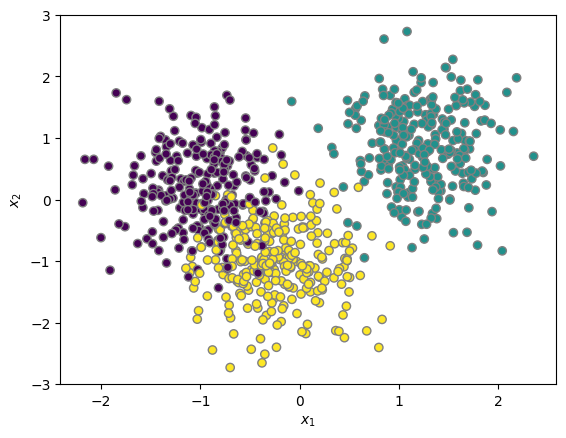

In [26]:
import matplotlib.pyplot as plt
from utils import make_classification_dataset, standard_scaler
from sklearn.model_selection import train_test_split

num_classes = 3
num_features = 2
X, y = make_classification_dataset(1000, num_features, num_classes, cluster_std=3) # try to change the cluster_std to see what happens

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardize X (try to comment this out and see what happens)
X_train, mean, std = standard_scaler(X_train)
X_test, _, _ = standard_scaler(X_test, mean, std)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

print(y_test)

# Plot the dataset
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="gray")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

print(f"X_train_min: {X_train.min()}, X_train_max: {X_train.max()}")

print(f"ymin: {y.min()}, ymax: {y.max()}")

## Training

In [27]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# Padronização das features (média 0, desvio padrão 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Hiperparâmetros de treinamento
num_epochs = 200
learning_rate = 1e-3

# Modelo: regressão logística multinomial (softmax + cross-entropy)
# Aqui usamos o treinamento padrão via .fit(), que internamente
# percorre o dataset por até max_iter épocas, mas atualiza os pesos
# amostra a amostra (batch_size = 1, SGD "puro" — não minibatch)
model = SGDClassifier(
    loss='log_loss',            # cross-entropy (equivalente a softmax multiclasse)
    penalty='l2',               # regularização L2
    alpha=0.0001,               # força da regularização (inverso do "C" do LogisticRegression)
    max_iter=num_epochs,        # número máximo de passadas completas pelo dataset
    learning_rate='constant',   # estrat. de atualização da taxa de aprendizado fixa (não decai a cada iteração)
    eta0=learning_rate,         # taxa de aprendizado inicial
    random_state=42,
    verbose=1
)

model.fit(X_train_scaled, y_train)

-- Epoch 1
Norm: 0.24, NNZs: 2, Bias: -0.125319, T: 800, Avg. loss: 0.643702
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.45, NNZs: 2, Bias: -0.228425, T: 1600, Avg. loss: 0.563742
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.63, NNZs: 2, Bias: -0.315072, T: 2400, Avg. loss: 0.505367
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.79, NNZs: 2, Bias: -0.389499, T: 3200, Avg. loss: 0.461154
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.93, NNZs: 2, Bias: -0.453631, T: 4000, Avg. loss: 0.426610
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.06, NNZs: 2, Bias: -0.511163, T: 4800, Avg. loss: 0.398851
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.18, NNZs: 2, Bias: -0.561777, T: 5600, Avg. loss: 0.376061
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.29, NNZs: 2, Bias: -0.607071, T: 6400, Avg. loss: 0.356996
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 1.39, NNZs: 2, Bias: -0.648703, T: 7200, Avg. loss: 0.340797
Total training time

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


SGDClassifier(eta0=0.001, learning_rate='constant', loss='log_loss',
              max_iter=200, random_state=42, verbose=1)

## Test

In [28]:
# Predict the labels
y_pred = model.predict(X_test)

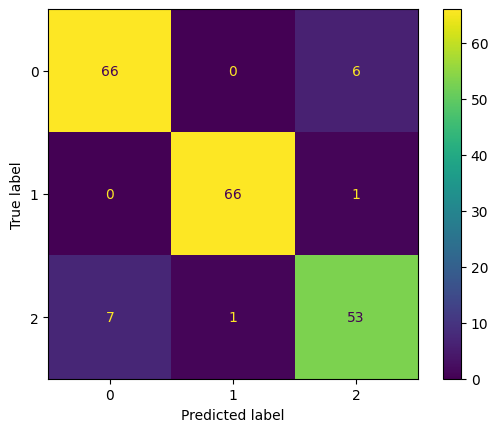


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        72
           1       0.99      0.99      0.99        67
           2       0.88      0.87      0.88        61

    accuracy                           0.93       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.93      0.92       200



In [29]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[class_id for class_id in range(num_classes)])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_id for class_id in range(num_classes)])
disp.plot()
plt.show()

# Compute classification report
class_report = classification_report(y_test, y_pred, target_names=[str(class_id) for class_id in range(num_classes)])

print("\nClassification Report:")
print(class_report)

In [30]:
import numpy as np

print("Predictions:", y_pred)
print("True labels:", y_test)

accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Predictions: [2 2 2 1 2 0 1 0 0 2 0 1 2 2 0 0 0 2 2 2 2 1 1 0 0 1 2 0 2 1 2 0 0 2 2 1 0
 0 0 2 1 2 1 0 0 1 0 2 2 2 1 1 1 2 0 0 0 0 2 1 1 1 0 0 1 2 2 1 2 2 0 1 1 1
 0 0 0 1 0 0 2 0 0 2 0 0 2 0 1 1 0 1 1 0 0 1 0 0 2 0 0 2 1 1 1 0 1 1 2 0 2
 2 0 0 0 1 2 1 2 0 2 0 2 0 2 0 0 2 1 2 2 0 1 1 1 0 2 0 1 1 2 0 1 1 1 2 1 2
 2 1 0 2 1 1 1 2 0 1 1 1 1 0 1 1 0 0 1 2 2 0 0 0 1 0 1 1 1 2 0 0 2 2 2 1 0
 0 1 2 2 1 0 0 1 2 0 1 0 1 2 1]
True labels: [2 2 2 1 2 0 1 0 0 2 0 1 2 2 0 0 0 2 2 2 2 1 2 0 0 1 2 0 2 1 2 0 0 2 2 1 0
 0 0 2 1 2 1 0 0 1 0 2 2 2 1 1 1 2 0 0 0 0 2 1 1 1 0 0 1 2 2 1 2 1 0 1 1 1
 0 0 0 1 0 0 2 0 0 2 0 2 2 0 1 1 0 1 1 0 0 1 0 0 2 0 0 0 1 1 1 0 1 1 2 0 2
 0 0 2 0 1 2 1 2 0 2 0 2 0 0 0 0 2 1 0 2 0 1 1 1 0 2 2 1 1 2 0 1 1 1 2 1 2
 2 1 2 2 1 1 1 2 0 1 1 1 1 0 1 1 0 0 1 2 0 2 0 0 1 0 1 1 1 2 0 0 2 2 2 1 0
 2 1 0 2 1 2 0 1 2 0 1 0 1 2 1]
Accuracy: 0.925
